# Deep Hedging: From Rules to Learned Risk Controls
**Docker image**: `ml4t-gpu`

**Chapter 19: Risk Management**
**Section Reference**: Section 19.7 (Adaptive Risk Controls)

## Purpose
This notebook demonstrates deep hedging (Buehler et al., 2019): a neural network learns
hedging positions that minimize CVaR of terminal losses under transaction costs. Where
Section 19.7 builds adaptive risk controls from rules (vol targeting, regime caps, stops),
this notebook optimizes a related tail-risk objective end-to-end with a neural network, linking
measurement (Section 19.3) to learned control without claiming that the two approaches are
equivalent.

## Learning Objectives
After completing this notebook, you will be able to:
- Simulate GBM paths and compute Black-Scholes delta as a rule-based benchmark
- Build a semi-recurrent neural network that outputs hedging positions
- Train the hedger using a differentiable CVaR loss objective
- Compare learned hedging to delta hedging under transaction costs
- Examine learned inaction conditional on distance from the delta benchmark

## Prerequisites
- Familiarity with option payoffs and Black-Scholes delta hedging
- Prior exposure to CVaR from Section 19.3
- The pinned CUDA environment declared above

## Cross-References
- **Upstream**: VaR/CVaR measurement (Section 19.3, [`01_var_cvar`](01_var_cvar.ipynb))
- **This chapter**: Adaptive controls (Section 19.7), SHAP diagnostics ([`05_trade_shap_diagnostics`](05_trade_shap_diagnostics.ipynb))
- **Downstream**: Full RL treatment (Chapter 21), production integration ([`10_ml4t_backtest_risk_demo`](10_ml4t_backtest_risk_demo.ipynb))
- **Reference**: Buehler et al. (2019), "Deep Hedging"

## Setup

In [1]:
"""Deep hedging under transaction costs and a tail-risk objective."""

import os
import random

import numpy as np
import plotly.graph_objects as go
import polars as pl
import torch
import torch.nn as nn
from IPython.display import Markdown, display
from plotly.subplots import make_subplots
from scipy.stats import norm

import utils.style  # noqa: F401
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [2]:
# Production defaults
N_PATHS = 50_000
N_STEPS = 30
S0 = 100.0
STRIKE = 100.0
MU = 0.05
SIGMA = 0.20
R = 0.0
DT = 1 / 252
COST_RATE = 0.001
CVAR_TAIL_PROBABILITY = 0.05
HIDDEN_SIZE = 32
N_EPOCHS = 100
LR = 5e-3
BATCH_SIZE = 2048
SEED = 42
SWEEP_SEED = 7_042
COST_SWEEP_EPOCHS = 10
COST_SWEEP_MAX_TRAIN_PATHS = 10_000
TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15
SIGNIFICANT_TRADE_THRESHOLD = 0.01

The publication path is fail-closed on CUDA and enables PyTorch's strict deterministic mode.
The pinned runner supplies the process-level cuBLAS and hash settings before Python starts.

In [3]:
if os.environ.get("CUBLAS_WORKSPACE_CONFIG") != ":4096:8":
    raise RuntimeError("CUBLAS_WORKSPACE_CONFIG=:4096:8 is required")
if os.environ.get("PYTHONHASHSEED") != str(SEED):
    raise RuntimeError(f"PYTHONHASHSEED={SEED} is required")
if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required; CPU fallback is disabled")
if torch.cuda.device_count() != 1:
    raise RuntimeError(f"Expected one visible CUDA device, found {torch.cuda.device_count()}")

torch.cuda.set_device(0)
torch.use_deterministic_algorithms(True, warn_only=False)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
set_global_seeds(SEED)
device = torch.device("cuda:0")

print(
    "GPU_DEVICE_PROOF "
    f"device_index={torch.cuda.current_device()} device_name={torch.cuda.get_device_name(0)!r} "
    "deterministic_algorithms=True cpu_fallback=False"
)

GPU_DEVICE_PROOF device_index=0 device_name='NVIDIA GeForce RTX 3090' deterministic_algorithms=True cpu_fallback=False


## The Hedging Problem

Section 19.7 presented rule-based adaptive controls: volatility targeting scales
positions by estimated vol, regime caps reduce exposure in stress, and stop-losses
exit at predefined thresholds. Each rule encodes human judgment about how positions
should respond to market conditions.

Deep hedging asks: what if we optimize the position-adjustment function *directly*?
Instead of designing rules, we define an objective: minimize CVaR of terminal losses,
and let a neural network learn the mapping from market information to positions.

### Formalization

A market maker sells a European call option, receiving premium $p_0$, and hedges by
trading the underlying at discrete times $t_0, \ldots, t_{n-1}$. The terminal PnL is:

$$PL_T = p_0 - Z + \sum_{k=0}^{n-1} \delta_k (S_{k+1} - S_k) - C_T(\delta)$$

where $Z = \max(S_T - K, 0)$ is the option payoff, $\delta_k$ is the hedge position,
and $C_T(\delta)$ charges the initial trade, every rebalance, and liquidation of the final
underlying position at $S_T$. The call is cash settled, so the hedge inventory must be closed.
Perfect hedging ($PL_T = 0$ for every path) is impossible under discrete rebalancing and costs.
The goal is to control the left tail of terminal PnL.

### Simulate GBM Paths

In [4]:
def simulate_gbm_paths(s0, mu, sigma, n_paths, n_steps, dt, seed=None):
    """Simulate geometric Brownian motion price paths.

    Returns tensor of shape (n_paths, n_steps + 1).
    """
    rng = np.random.default_rng(seed)
    z = rng.standard_normal(size=(n_paths, n_steps)).astype(np.float32)

    drift = (mu - 0.5 * sigma**2) * dt
    vol = sigma * np.sqrt(dt)

    log_returns = drift + vol * z
    log_prices = np.concatenate(
        [np.zeros((n_paths, 1), dtype=np.float32), np.cumsum(log_returns, axis=1)],
        axis=1,
    )
    return torch.tensor(s0 * np.exp(log_prices), device=device)

In [5]:
paths = simulate_gbm_paths(S0, MU, SIGMA, N_PATHS, N_STEPS, DT, seed=SEED)
print(f"Simulated {N_PATHS:,} paths, {N_STEPS} steps: shape {tuple(paths.shape)}")

Simulated 50,000 paths, 30 steps: shape (50000, 31)


### Black-Scholes Pricing and Delta

In [6]:
def bs_price_delta(spot, strike, tau, sigma, r=0.0):
    """Vectorized Black-Scholes call price and delta.

    All inputs are numpy arrays or scalars. Returns (price, delta) as numpy arrays.
    """
    spot = np.asarray(spot, dtype=np.float64)
    tau = np.asarray(tau, dtype=np.float64)

    eps = 1e-12
    sqrt_tau = np.sqrt(np.maximum(tau, eps))
    d1 = (np.log(np.maximum(spot, eps) / strike) + (r + 0.5 * sigma**2) * tau) / (
        sigma * sqrt_tau + eps
    )
    d2 = d1 - sigma * sqrt_tau

    price = spot * norm.cdf(d1) - strike * np.exp(-r * tau) * norm.cdf(d2)
    delta = norm.cdf(d1)

    return price.astype(np.float32), delta.astype(np.float32)

Compute Black-Scholes delta at each rebalancing date for all paths.

In [7]:
# Time to maturity at each step (decreasing)
tau_grid = np.array([(N_STEPS - k) * DT for k in range(N_STEPS)], dtype=np.float32)

# BS delta for each path and step: shape (n_paths, n_steps)
spot_np = paths[:, :-1].cpu().numpy()
tau_broadcast = np.broadcast_to(tau_grid, spot_np.shape)
_, bs_delta = bs_price_delta(spot_np, STRIKE, tau_broadcast, SIGMA, R)
bs_delta_t = torch.tensor(bs_delta, device=device)

# Option premium (BS price at t=0)
premium_scalar, _ = bs_price_delta(S0, STRIKE, N_STEPS * DT, SIGMA, R)
premium = torch.full((N_PATHS,), float(premium_scalar), device=device)

print(f"BS premium (t=0): {premium_scalar:.4f}")
print(f"BS delta range: [{bs_delta.min():.4f}, {bs_delta.max():.4f}]")

BS premium (t=0): 2.7524
BS delta range: [0.0000, 1.0000]


### Visualize Sample Paths with Delta Overlay

In [8]:
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
    subplot_titles=["Simulated underlying paths", "Black-Scholes delta"],
)

n_show = 5
path_colors = [
    COLORS["blue"],
    COLORS["copper"],
    COLORS["amber"],
    COLORS["positive"],
    COLORS["negative"],
]

Matching colors link each solid price path to its dotted delta path.

In [9]:
for i in range(n_show):
    fig.add_trace(
        go.Scatter(
            y=paths[i].cpu().numpy(),
            mode="lines",
            name=f"Path {i + 1}",
            legendgroup=f"path-{i}",
            line=dict(color=path_colors[i]),
            opacity=0.7,
        ),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Scatter(
            y=bs_delta[i],
            mode="lines",
            legendgroup=f"path-{i}",
            line=dict(color=path_colors[i], dash="dot"),
            opacity=0.7,
            showlegend=False,
        ),
        row=2,
        col=1,
    )

The strike reference and axis units complete the two-panel diagnostic.

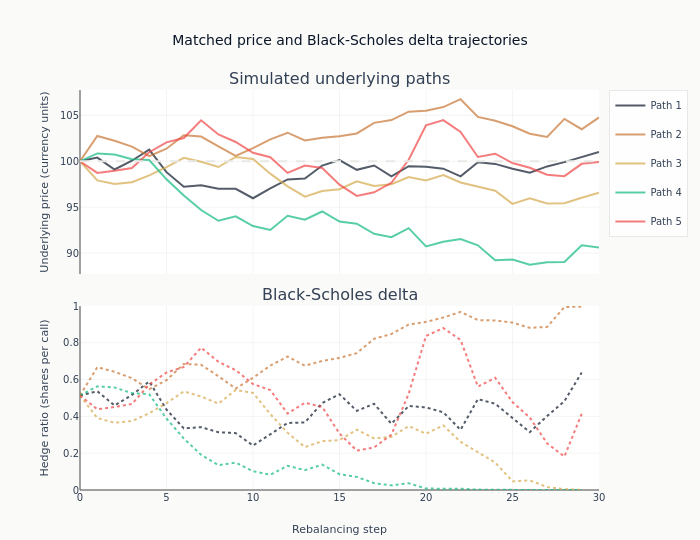

In [10]:
fig.add_hline(y=STRIKE, line_dash="dash", line_color=COLORS["silver_muted"], row=1, col=1)
fig.update_yaxes(title_text="Underlying price (currency units)", row=1, col=1)
fig.update_yaxes(title_text="Hedge ratio (shares per call)", range=[0, 1], row=2, col=1)
fig.update_xaxes(title_text="Rebalancing step", row=2, col=1)
fig.update_layout(
    title="Matched price and Black-Scholes delta trajectories",
    height=540,
    margin=dict(t=90, b=50),
)
fig.show()

## Baseline: Black-Scholes Delta Hedging

The analytical delta formula comes from a continuous, frictionless, constant-volatility model.
The implemented benchmark applies that formula on this notebook's discrete grid and charges the
same opening, rebalancing, and liquidation costs as the learned hedge.

In [11]:
def compute_hedge_pnl(positions, paths, payoff, premium, cost_rate=0.0):
    """Compute terminal PnL for a hedging strategy.

    positions: (n_paths, n_steps), shares held over each interval
    paths: (n_paths, n_steps + 1), including the terminal price
    payoff: (n_paths,), cash-settled option payoff at maturity
    premium: (n_paths,), premium received
    cost_rate: proportional transaction cost rate
    """
    price_changes = paths[:, 1:] - paths[:, :-1]
    hedging_gains = (positions * price_changes).sum(dim=1)

    # Include opening, every rebalance, and terminal liquidation.
    position_changes = torch.diff(
        torch.cat(
            [
                torch.zeros(positions.shape[0], 1, device=positions.device, dtype=positions.dtype),
                positions,
                torch.zeros(positions.shape[0], 1, device=positions.device, dtype=positions.dtype),
            ],
            dim=1,
        ),
        dim=1,
    )
    costs = (cost_rate * position_changes.abs() * paths).sum(dim=1)

    return premium - payoff + hedging_gains - costs

In [12]:
payoff = torch.relu(paths[:, -1] - STRIKE)

### Reporting Helpers

In [13]:
def compute_cvar(pnl, tail_probability=0.05):
    """Sample CVaR (expected shortfall) of losses = -PnL."""
    losses = -pnl
    k = max(int(round(tail_probability * len(losses))), 1)
    worst, _ = torch.topk(losses, k=k, largest=True)
    return float(worst.mean().item())

These helper summaries keep the reporting comparable across the unhedged, delta-hedged, and
learned strategies.

In [14]:
def pnl_stats(pnl, label=""):
    """Return dict of PnL statistics."""
    return {
        "strategy": label,
        "mean": float(pnl.mean()),
        "std": float(pnl.std()),
        "cvar_95": compute_cvar(pnl, 0.05),
        "cvar_99": compute_cvar(pnl, 0.01),
        "min": float(pnl.min()),
    }


# The strategy comparison is deferred until the sealed test split is opened.

## The Deep Hedger

Following Buehler et al. (2019), we parameterize the hedge position at each step as:

$$\delta_k = F_k(I_k, \delta_{k-1})$$

where $I_k$ is the information set (moneyness, time-to-maturity, implied vol, log return)
and $\delta_{k-1}$ is the previous position. Each timestep has its own MLP $F_k$, making
the architecture *semi-recurrent*: positions feed forward, but there is no shared hidden
state or backpropagation through time beyond the position variable.

Each rebalancing step uses the same compact network shape but retains separate weights.

In [15]:
def make_step_network(input_size, hidden_size):
    """Build one timestep's position network."""
    return nn.Sequential(
        nn.Linear(input_size, hidden_size),
        nn.ReLU(),
        nn.Linear(hidden_size, hidden_size),
        nn.ReLU(),
        nn.Linear(hidden_size, 1),
    )

The hedger carries the previous position forward, making trading friction part of the state.

In [16]:
class DeepHedger(nn.Module):
    """Semi-recurrent deep hedging network."""

    def __init__(self, n_steps, n_features, hidden_size=32, max_position=1.5):
        super().__init__()
        self.n_steps = n_steps
        input_size = n_features + 1
        self.nets = nn.ModuleList(
            [make_step_network(input_size, hidden_size) for _ in range(n_steps)]
        )
        self.max_position = max_position

    def forward(self, info):
        """Map market information to interval hedge positions."""
        batch = info.shape[0]
        positions = []
        prev_pos = torch.zeros(batch, 1, device=info.device)
        for k in range(self.n_steps):
            x = torch.cat([info[:, k, :], prev_pos], dim=1)
            pos = self.nets[k](x)
            if self.max_position is not None:
                pos = torch.tanh(pos) * self.max_position
            positions.append(pos)
            prev_pos = pos
        return torch.cat(positions, dim=1)

## CVaR as Differentiable Training Objective

In Section 19.3 we defined CVaR as a coherent risk measure for evaluating tail losses.
Now we use it as a *loss function* for training. The key is the Rockafellar-Uryasev
representation:

$$\text{CVaR}_{1-q}(L) = \min_w \left[ w + \frac{1}{q} \mathbb{E}\left[(L - w)_+\right] \right]$$

where $L = -PL_T$ and $q=0.05$ is the tail probability, corresponding to the book's 95%
confidence convention. The threshold $w$ is learned jointly with the hedge. This optimized OCE
objective is distinct from the empirical sample CVaR reported on validation and test paths.

In [17]:
class CVaRLoss(nn.Module):
    """Differentiable CVaR loss via the OCE representation.

    At a minimizing solution, the learnable threshold w corresponds to a VaR quantile.
    """

    def __init__(self, tail_probability=0.05):
        super().__init__()
        self.tail_probability = tail_probability
        self.w = nn.Parameter(torch.tensor(0.0))

    def forward(self, pnl):
        """Compute CVaR of losses = -pnl."""
        losses = -pnl
        excess = torch.relu(losses - self.w)
        return self.w + excess.mean() / self.tail_probability

## Prepare Training Data

The information set $I_k$ at each step includes:
- **Log-moneyness**: $\log(S_k / K)$, where the option is relative to the strike
- **Time-to-maturity**: $\tau_k$, the normalized remaining time
- **Implied vol proxy**: constant $\sigma$ under GBM (real data would use market IV)
- **Log return**: $\log(S_k / S_{k-1})$, the recent price move

In [18]:
def prepare_info(paths, strike, sigma, n_steps, dt):
    """Build the information tensor for the deep hedger.

    Returns tensor of shape (n_paths, n_steps, 4).
    """
    spot = paths[:, :-1]  # (n_paths, n_steps)

    log_moneyness = torch.log(spot / strike)
    tau = (
        torch.tensor(
            [(n_steps - k) * dt for k in range(n_steps)], device=paths.device, dtype=paths.dtype
        )
        .unsqueeze(0)
        .expand(spot.shape[0], -1)
    )
    vol = torch.full_like(spot, sigma)
    log_ret = torch.zeros_like(spot)
    log_ret[:, 1:] = torch.log(paths[:, 1:-1] / paths[:, :-2])

    return torch.stack([log_moneyness, tau, vol, log_ret], dim=2).float()

In [19]:
info = prepare_info(paths, STRIKE, SIGMA, N_STEPS, DT)
print(f"Information tensor: {tuple(info.shape)} [log_moneyness, tau, vol, log_return]")

Information tensor: (50000, 30, 4) [log_moneyness, tau, vol, log_return]


The seeded simulator produces independent paths. Training fits the policy, validation monitors
optimization and supports the exploratory cost sweep, and the final test split remains sealed
until the main policy is frozen. No chronological purge is needed for independent simulated paths.

In [20]:
n_train = int(TRAIN_FRACTION * N_PATHS)
n_validation = int(VALIDATION_FRACTION * N_PATHS)
n_test = N_PATHS - n_train - n_validation
train_idx = slice(0, n_train)
validation_idx = slice(n_train, n_train + n_validation)
test_idx = slice(n_train + n_validation, N_PATHS)

info_train, info_validation, info_test = info[train_idx], info[validation_idx], info[test_idx]
paths_train, paths_validation, paths_test = paths[train_idx], paths[validation_idx], paths[test_idx]
payoff_train = payoff[train_idx]
payoff_validation, payoff_test = payoff[validation_idx], payoff[test_idx]
premium_train = premium[train_idx]
premium_validation, premium_test = premium[validation_idx], premium[test_idx]

print(f"Train: {n_train:,} | Validation: {n_validation:,} | Sealed test: {n_test:,} paths")

Train: 35,000 | Validation: 7,500 | Sealed test: 7,500 paths


## Training

Every publication run trains from scratch. The notebook has no cache or checkpoint branch.
Adam updates the policy and OCE threshold together; gradient clipping limits the influence of
extreme batches.

Resetting all model and shuffle state makes each cost-sweep treatment comparable.

In [21]:
def reset_torch_training_state(seed):
    """Reset CPU and CUDA generators before constructing a model."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

One training epoch uses an explicit CUDA generator for a reproducible path order.

In [22]:
def train_one_epoch(model, criterion, optimizer, tensors, cost_rate, generator):
    """Run one shuffled training epoch and return mean OCE loss."""
    info_set, paths_set, payoff_set, premium_set = tensors
    model.train()
    permutation = torch.randperm(len(info_set), device=device, generator=generator)
    weighted_loss = 0.0
    observations = 0
    for start in range(0, len(info_set), BATCH_SIZE):
        idx = permutation[start : start + BATCH_SIZE]
        positions = model(info_set[idx])
        pnl = compute_hedge_pnl(
            positions, paths_set[idx], payoff_set[idx], premium_set[idx], cost_rate
        )
        loss = criterion(pnl)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        batch_size = len(idx)
        weighted_loss += loss.item() * batch_size
        observations += batch_size
    return weighted_loss / observations

Evaluation reports empirical sample CVaR rather than reusing the learned OCE threshold.

In [23]:
def evaluate_hedger(model, info_set, paths_set, payoff_set, premium_set, cost_rate):
    """Return positions and terminal PnL without updating model state."""
    model.eval()
    with torch.no_grad():
        positions = model(info_set)
        pnl = compute_hedge_pnl(positions, paths_set, payoff_set, premium_set, cost_rate)
    return positions, pnl

In [24]:
N_FEATURES = info.shape[2]
reset_torch_training_state(SEED)
main_generator = torch.Generator(device="cuda").manual_seed(SEED)
model = DeepHedger(N_STEPS, N_FEATURES, hidden_size=HIDDEN_SIZE).to(device)
criterion = CVaRLoss(tail_probability=CVAR_TAIL_PROBABILITY).to(device)
optimizer = torch.optim.Adam(list(model.parameters()) + list(criterion.parameters()), lr=LR)
training_tensors = (info_train, paths_train, payoff_train, premium_train)
train_oce_losses = []
validation_cvar_losses = []

if next(model.parameters()).device != device or info_train.device != device:
    raise RuntimeError("Model and training tensors must reside on cuda:0")
print(f"TORCH_MODEL_DEVICE_PROOF model={next(model.parameters()).device} data={info_train.device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Architecture: {N_STEPS} MLPs, each ({N_FEATURES}+1) -> {HIDDEN_SIZE} -> {HIDDEN_SIZE} -> 1")

TORCH_MODEL_DEVICE_PROOF model=cuda:0 data=cuda:0
Model parameters: 38,430
Architecture: 30 MLPs, each (4+1) -> 32 -> 32 -> 1


Validation is used only to monitor the frozen training schedule, not to choose an epoch.

In [25]:
for epoch in range(N_EPOCHS):
    train_loss = train_one_epoch(
        model, criterion, optimizer, training_tensors, COST_RATE, main_generator
    )
    _, validation_pnl = evaluate_hedger(
        model,
        info_validation,
        paths_validation,
        payoff_validation,
        premium_validation,
        COST_RATE,
    )
    validation_cvar = compute_cvar(validation_pnl, CVAR_TAIL_PROBABILITY)
    train_oce_losses.append(train_loss)
    validation_cvar_losses.append(validation_cvar)
    if (epoch + 1) % 20 == 0 or epoch == 0:
        print(
            f"Epoch {epoch + 1:3d}/{N_EPOCHS} | Train OCE: {train_loss:.4f} | "
            f"Validation sample CVaR: {validation_cvar:.4f}"
        )

print(f"MAIN_TRAINING_COMPUTE_PROOF epochs={N_EPOCHS} cache_used=False device={device}")

Epoch   1/100 | Train OCE: 26.5838 | Validation sample CVaR: 5.4652


Epoch  20/100 | Train OCE: 1.4004 | Validation sample CVaR: 1.3195


Epoch  40/100 | Train OCE: 1.2751 | Validation sample CVaR: 1.3279


Epoch  60/100 | Train OCE: 1.2764 | Validation sample CVaR: 1.2957


Epoch  80/100 | Train OCE: 1.2364 | Validation sample CVaR: 1.3144


Epoch 100/100 | Train OCE: 1.2444 | Validation sample CVaR: 1.3030
MAIN_TRAINING_COMPUTE_PROOF epochs=100 cache_used=False device=cuda:0


### Learning Curves

A log scale shows proportional changes across the optimization path. The two lines measure related
but different quantities: minibatch OCE during fitting and sample CVaR on validation.

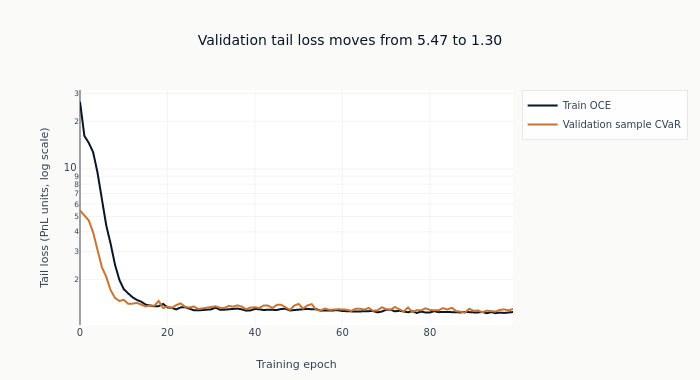

In [26]:
all_curve_losses = np.array(train_oce_losses + validation_cvar_losses)
if np.any(all_curve_losses <= 0):
    raise RuntimeError("Learning-curve log scale requires positive tail losses")
fig = go.Figure()
fig.add_trace(
    go.Scatter(y=train_oce_losses, name="Train OCE", mode="lines", line=dict(color=COLORS["blue"]))
)
fig.add_trace(
    go.Scatter(
        y=validation_cvar_losses,
        name="Validation sample CVaR",
        mode="lines",
        line=dict(color=COLORS["copper"]),
    )
)
fig.update_layout(
    title=(
        f"Validation tail loss moves from {validation_cvar_losses[0]:.2f} "
        f"to {validation_cvar_losses[-1]:.2f}"
    ),
    xaxis_title="Training epoch",
    yaxis_title="Tail loss (PnL units, log scale)",
    yaxis_type="log",
    height=380,
    margin=dict(t=90, b=55),
)
fig.show()

Significant-trade counts include opening, every rebalance, and terminal liquidation.

In [27]:
def mean_significant_trades(positions, threshold):
    """Count mean lifecycle trades whose absolute size exceeds a threshold."""
    zeros = torch.zeros(positions.shape[0], 1, device=positions.device, dtype=positions.dtype)
    lifecycle = torch.cat([zeros, positions, zeros], dim=1)
    return float((torch.diff(lifecycle, dim=1).abs() > threshold).float().sum(dim=1).mean())

## Transaction Cost Sensitivity

The exploratory sweep trains a fresh policy at each cost level on the same training paths and
evaluates it on validation paths. Resetting initialization and minibatch order before every model
isolates the cost treatment from advancing random state. The sweep never opens the sealed test.

In [28]:
cost_levels = [0.0, 0.0001, 0.0005, 0.001, 0.005]
sweep_n_train = min(COST_SWEEP_MAX_TRAIN_PATHS, n_train)
sweep_training_tensors = (
    info_train[:sweep_n_train],
    paths_train[:sweep_n_train],
    payoff_train[:sweep_n_train],
    premium_train[:sweep_n_train],
)
print(f"Cost sweep training: {sweep_n_train:,} paths, {COST_SWEEP_EPOCHS} epochs per cost")

Cost sweep training: 10,000 paths, 10 epochs per cost


Each treatment returns both tail loss and a matched delta trade-count benchmark.

In [29]:
def train_cost_level(cost_rate):
    """Train one matched-seed cost treatment and evaluate it on validation paths."""
    reset_torch_training_state(SWEEP_SEED)
    generator = torch.Generator(device="cuda").manual_seed(SWEEP_SEED)
    sweep_model = DeepHedger(N_STEPS, N_FEATURES, hidden_size=HIDDEN_SIZE).to(device)
    sweep_loss = CVaRLoss(tail_probability=CVAR_TAIL_PROBABILITY).to(device)
    sweep_optimizer = torch.optim.Adam(
        list(sweep_model.parameters()) + list(sweep_loss.parameters()), lr=LR
    )
    sweep_training_args = (sweep_model, sweep_loss, sweep_optimizer, sweep_training_tensors)
    for _ in range(COST_SWEEP_EPOCHS):
        train_one_epoch(*sweep_training_args, cost_rate, generator)
    positions, deep_pnl = evaluate_hedger(
        sweep_model,
        info_validation,
        paths_validation,
        payoff_validation,
        premium_validation,
        cost_rate,
    )
    delta_pnl = compute_hedge_pnl(
        bs_delta_t[validation_idx],
        paths_validation,
        payoff_validation,
        premium_validation,
        cost_rate,
    )
    return {
        "cost": cost_rate,
        "delta_cvar": compute_cvar(delta_pnl, CVAR_TAIL_PROBABILITY),
        "deep_cvar": compute_cvar(deep_pnl, CVAR_TAIL_PROBABILITY),
        "delta_mean_trades": mean_significant_trades(
            bs_delta_t[validation_idx], SIGNIFICANT_TRADE_THRESHOLD
        ),
        "deep_mean_trades": mean_significant_trades(positions, SIGNIFICANT_TRADE_THRESHOLD),
    }

In [30]:
cost_results = []
for cost in cost_levels:
    print(f"COST_SWEEP_MODEL_START cost={cost:.4f} seed={SWEEP_SEED}")
    result = train_cost_level(cost)
    cost_results.append(result)
    print(
        f"COST_SWEEP_MODEL_COMPUTE_PROOF cost={cost:.4f} seed={SWEEP_SEED} "
        f"deep_cvar={result['deep_cvar']:.4f} deep_trades={result['deep_mean_trades']:.2f}"
    )
print(f"COST_SWEEP_COMPUTE_PROOF models={len(cost_results)} cache_used=False")

COST_SWEEP_MODEL_START cost=0.0000 seed=7042


COST_SWEEP_MODEL_COMPUTE_PROOF cost=0.0000 seed=7042 deep_cvar=4.1114 deep_trades=28.08
COST_SWEEP_MODEL_START cost=0.0001 seed=7042


COST_SWEEP_MODEL_COMPUTE_PROOF cost=0.0001 seed=7042 deep_cvar=4.1446 deep_trades=25.63
COST_SWEEP_MODEL_START cost=0.0005 seed=7042


COST_SWEEP_MODEL_COMPUTE_PROOF cost=0.0005 seed=7042 deep_cvar=4.6425 deep_trades=23.43
COST_SWEEP_MODEL_START cost=0.0010 seed=7042


COST_SWEEP_MODEL_COMPUTE_PROOF cost=0.0010 seed=7042 deep_cvar=4.8349 deep_trades=20.08
COST_SWEEP_MODEL_START cost=0.0050 seed=7042


COST_SWEEP_MODEL_COMPUTE_PROOF cost=0.0050 seed=7042 deep_cvar=6.4628 deep_trades=16.30
COST_SWEEP_COMPUTE_PROOF models=5 cache_used=False


The cost levels are categorical basis-point treatments, not a continuous fitted curve. The short
matched-budget sweep diagnoses cost response; it is not a ranking of converged policies.

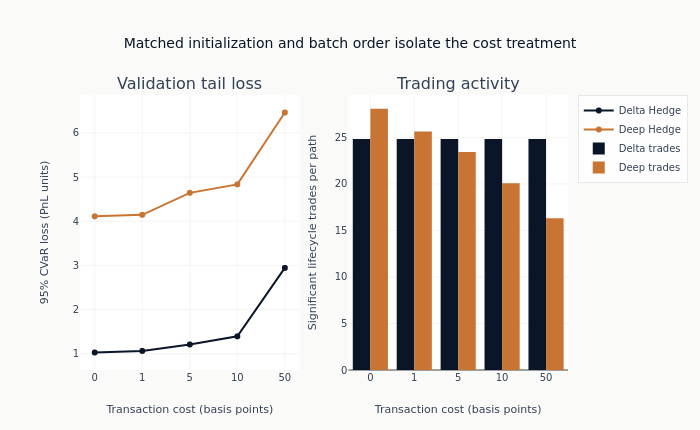

In [31]:
cost_labels = [f"{10_000 * row['cost']:.0f}" for row in cost_results]
deep_cvars = [row["deep_cvar"] for row in cost_results]
delta_cvars = [row["delta_cvar"] for row in cost_results]
deep_trades_by_cost = [row["deep_mean_trades"] for row in cost_results]
delta_trades_by_cost = [row["delta_mean_trades"] for row in cost_results]
fig = make_subplots(rows=1, cols=2, subplot_titles=["Validation tail loss", "Trading activity"])
fig.add_trace(
    go.Scatter(x=cost_labels, y=delta_cvars, name="Delta Hedge", line=dict(color=COLORS["blue"])),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(x=cost_labels, y=deep_cvars, name="Deep Hedge", line=dict(color=COLORS["copper"])),
    row=1,
    col=1,
)
fig.add_trace(
    go.Bar(x=cost_labels, y=delta_trades_by_cost, name="Delta trades", marker_color=COLORS["blue"]),
    row=1,
    col=2,
)
fig.add_trace(
    go.Bar(x=cost_labels, y=deep_trades_by_cost, name="Deep trades", marker_color=COLORS["copper"]),
    row=1,
    col=2,
)
fig.update_xaxes(title_text="Transaction cost (basis points)", type="category")
fig.update_yaxes(title_text="95% CVaR loss (PnL units)", row=1, col=1)
fig.update_yaxes(title_text="Significant lifecycle trades per path", row=1, col=2)
fig.update_layout(
    title="Matched initialization and batch order isolate the cost treatment",
    barmode="group",
    height=430,
    margin=dict(t=95, b=60),
)
fig.show()

The computed sweep commentary distinguishes an observed endpoint change from monotonic behavior.

In [32]:
trade_differences = np.diff(deep_trades_by_cost)
monotone_text = "monotone" if np.all(trade_differences <= 0) else "not monotone"
display(
    Markdown(
        f"Across this short matched-seed validation sweep, deep-policy activity changes from "
        f"**{deep_trades_by_cost[0]:.1f}** to **{deep_trades_by_cost[-1]:.1f}** significant "
        f"lifecycle trades per path and is **{monotone_text}** across intermediate costs. "
        "The limited training budget makes this a sensitivity diagnostic, not evidence of robust "
        "performance dominance."
    )
)

Across this short matched-seed validation sweep, deep-policy activity changes from **28.1** to **16.3** significant lifecycle trades per path and is **monotone** across intermediate costs. The limited training budget makes this a sensitivity diagnostic, not evidence of robust performance dominance.

## Results: Sealed Three-Way Comparison

All model fitting and validation exploration are complete. The frozen main policy is now evaluated
once on the sealed test paths alongside the naked option and Black-Scholes delta hedge. This GBM
experiment illustrates behavior under its stated assumptions; it does not establish dominance.

In [33]:
deep_positions, pnl_deep = evaluate_hedger(
    model, info_test, paths_test, payoff_test, premium_test, COST_RATE
)
pnl_delta_test = compute_hedge_pnl(
    bs_delta_t[test_idx], paths_test, payoff_test, premium_test, COST_RATE
)
pnl_no_hedge_test = premium_test - payoff_test
results = [
    pnl_stats(pnl_no_hedge_test, "No Hedge"),
    pnl_stats(pnl_delta_test, f"Delta Hedge (cost={COST_RATE})"),
    pnl_stats(pnl_deep, f"Deep Hedge (cost={COST_RATE})"),
]
print(f"SEALED_TEST_OPEN_PROOF paths={n_test} evaluations=1 post_selection=True")

SEALED_TEST_OPEN_PROOF paths=7500 evaluations=1 post_selection=True


The exact test metrics are generated from the result object so they cannot drift from a rerun.

In [34]:
result_lines = [
    "| Strategy | Mean PnL | PnL std. dev. | 95% CVaR loss |",
    "|:--|--:|--:|--:|",
]
for row in results:
    result_lines.append(
        f"| {row['strategy']} | {row['mean']:.4f} | {row['std']:.4f} | {row['cvar_95']:.4f} |"
    )
display(Markdown("\n".join(result_lines)))

| Strategy | Mean PnL | PnL std. dev. | 95% CVaR loss |
|:--|--:|--:|--:|
| No Hedge | -0.3086 | 4.4507 | 13.0874 |
| Delta Hedge (cost=0.001) | -0.2789 | 0.4535 | 1.3948 |
| Deep Hedge (cost=0.001) | -0.2687 | 0.5353 | 1.2893 |

An empirical CDF avoids the large no-hedge point mass obscuring the two hedged distributions.
The right panel magnifies the hedged strategies' worst decile, where CVaR differences matter.

Sorting terminal PnL supplies coordinates for the empirical distribution function.

In [35]:
def empirical_cdf(values):
    """Return sorted observations and empirical cumulative probabilities."""
    x = np.sort(values.detach().cpu().numpy())
    return x, np.arange(1, len(x) + 1) / len(x)

In [36]:
distribution_series = [
    (pnl_no_hedge_test, "No Hedge", COLORS["negative"]),
    (pnl_delta_test, "Delta Hedge", COLORS["blue"]),
    (pnl_deep, "Deep Hedge", COLORS["copper"]),
]
figure_winner = min(results, key=lambda row: row["cvar_95"])["strategy"].split(" (")[0]
fig = make_subplots(rows=1, cols=2, subplot_titles=["Full distribution", "Worst-decile detail"])
for pnl_data, name, color in distribution_series:
    x, y = empirical_cdf(pnl_data)
    fig.add_trace(go.Scatter(x=x, y=y, name=name, line=dict(color=color)), row=1, col=1)
    if name != "No Hedge":
        mask = y <= 0.10
        fig.add_trace(
            go.Scatter(x=x[mask], y=y[mask], name=name, line=dict(color=color), showlegend=False),
            row=1,
            col=2,
        )

Zero-PnL references distinguish gains from losses; the dotted horizontal line marks the 5% tail.

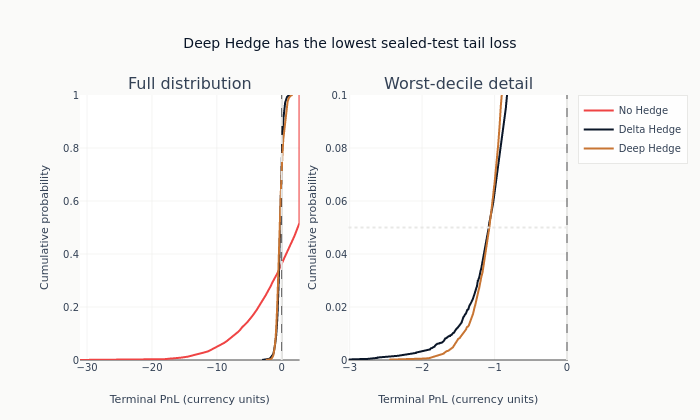

In [37]:
for column in (1, 2):
    fig.add_vline(x=0, line_dash="dash", line_color=COLORS["silver_muted"], row=1, col=column)
fig.add_hline(y=0.05, line_dash="dot", line_color=COLORS["silver_muted"], row=1, col=2)
fig.update_xaxes(title_text="Terminal PnL (currency units)")
fig.update_yaxes(title_text="Cumulative probability", range=[0, 1], row=1, col=1)
fig.update_yaxes(title_text="Cumulative probability", range=[0, 0.10], row=1, col=2)
fig.update_layout(
    title=f"{figure_winner} has the lowest sealed-test tail loss",
    height=420,
    margin=dict(t=95, b=60),
)
fig.show()

The interpretation below is also generated from the sealed-test result object.

In [38]:
deep_result = results[2]
delta_result = results[1]
mean_relation = "higher" if deep_result["mean"] > delta_result["mean"] else "lower"
dispersion_relation = "wider" if deep_result["std"] > delta_result["std"] else "narrower"
tail_relation = "lower" if deep_result["cvar_95"] < delta_result["cvar_95"] else "higher"
display(
    Markdown(
        f"On the sealed test paths, the deep hedge has **{mean_relation} mean PnL**, "
        f"a **{dispersion_relation} standard deviation**, and **{tail_relation} 95% CVaR loss** "
        "than delta hedging. The comparison separates tail behavior from overall dispersion."
    )
)

On the sealed test paths, the deep hedge has **higher mean PnL**, a **wider standard deviation**, and **lower 95% CVaR loss** than delta hedging. The comparison separates tail behavior from overall dispersion.

## Conditional Inaction Diagnostic

Proportional costs can make inaction economically useful. Here Black-Scholes delta is only a
benchmark, not the learned policy's unobserved frictionless target. Conditioning adjustment size on
distance from that benchmark describes association; it does not identify an optimal no-trade band.

Fixed benchmark-gap bins make the conditional summary comparable across reruns.

In [39]:
def conditional_inaction_diagnostic(positions, benchmark_delta, threshold):
    """Summarize learned adjustment and inaction conditional on a delta benchmark gap."""
    zeros = torch.zeros(positions.shape[0], 1, device=positions.device, dtype=positions.dtype)
    previous = torch.cat([zeros, positions[:, :-1]], dim=1)
    gap = (benchmark_delta - previous).abs().detach().cpu().numpy().ravel()
    adjustment = (positions - previous).abs().detach().cpu().numpy().ravel()
    edges = np.array([0.0, 0.02, 0.05, 0.10, 0.20, 0.50, np.inf])
    labels = ["0-.02", ".02-.05", ".05-.10", ".10-.20", ".20-.50", ".50+"]
    bin_index = np.digitize(gap, edges[1:-1], right=False)
    rows = []
    for index, label in enumerate(labels):
        selected = adjustment[bin_index == index]
        rows.append(
            {
                "benchmark_gap": label,
                "mean_adjustment": None if len(selected) == 0 else float(selected.mean()),
                "inaction_share": None
                if len(selected) == 0
                else float((selected <= threshold).mean()),
                "observations": len(selected),
            }
        )
    return pl.DataFrame(rows)

In [40]:
delta_test = bs_delta_t[test_idx]
inaction_df = conditional_inaction_diagnostic(
    deep_positions, delta_test, SIGNIFICANT_TRADE_THRESHOLD
)
empty_bins = inaction_df.filter(pl.col("observations") == 0)["benchmark_gap"].to_list()
if empty_bins:
    raise RuntimeError(f"Conditional inaction diagnostic has empty bins: {empty_bins}")
deep_mean_trades = mean_significant_trades(deep_positions, SIGNIFICANT_TRADE_THRESHOLD)
delta_mean_trades = mean_significant_trades(delta_test, SIGNIFICANT_TRADE_THRESHOLD)
small_gap_inaction = inaction_df[0, "inaction_share"]
large_gap_inaction = inaction_df[-1, "inaction_share"]
if np.isclose(small_gap_inaction, large_gap_inaction):
    inaction_title = "Inaction is similar at small and large delta-benchmark gaps"
elif small_gap_inaction > large_gap_inaction:
    inaction_title = "Inaction is higher for small than large delta-benchmark gaps"
else:
    inaction_title = "Inaction is lower for small than large delta-benchmark gaps"

In [41]:
observation_counts = inaction_df["observations"].to_numpy().reshape(-1, 1)
fig = make_subplots(rows=1, cols=2, subplot_titles=["Mean learned adjustment", "Inaction share"])
fig.add_trace(
    go.Bar(
        x=inaction_df["benchmark_gap"],
        y=inaction_df["mean_adjustment"],
        customdata=observation_counts,
        hovertemplate="Gap %{x}<br>Adjustment %{y:.3f}<br>n=%{customdata[0]}<extra></extra>",
        marker_color=COLORS["blue"],
    ),
    row=1,
    col=1,
)
_ = fig.add_trace(
    go.Bar(
        x=inaction_df["benchmark_gap"],
        y=inaction_df["inaction_share"],
        customdata=observation_counts,
        hovertemplate="Gap %{x}<br>Inaction %{y:.1%}<br>n=%{customdata[0]}<extra></extra>",
        marker_color=COLORS["copper"],
    ),
    row=1,
    col=2,
)

The share axis and title disclose the configured threshold and the endpoint comparison.

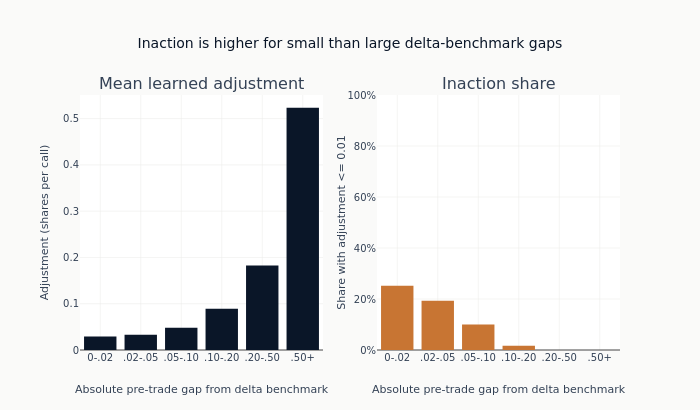

In [42]:
fig.update_xaxes(title_text="Absolute pre-trade gap from delta benchmark")
fig.update_yaxes(title_text="Adjustment (shares per call)", row=1, col=1)
fig.update_yaxes(
    title_text=f"Share with adjustment <= {SIGNIFICANT_TRADE_THRESHOLD:.2f}",
    tickformat=".0%",
    range=[0, 1],
    row=1,
    col=2,
)
fig.update_layout(
    title=inaction_title,
    height=410,
    showlegend=False,
    margin=dict(t=95, b=60),
)
fig.show()

The statement below reports the computed association, sample sizes, and its identification limit.

In [43]:
display(
    Markdown(
        f"At the disclosed **{SIGNIFICANT_TRADE_THRESHOLD:.2f}-share threshold**, inaction is "
        f"**{small_gap_inaction:.1%}** for gaps below 0.02 "
        f"(n={inaction_df[0, 'observations']:,}) and **{large_gap_inaction:.1%}** for gaps above "
        f"0.50 (n={inaction_df[-1, 'observations']:,}). This conditional association does not "
        "identify a no-transaction region. Across the full lifecycle, the deep and delta policies "
        f"average **{deep_mean_trades:.1f}** and **{delta_mean_trades:.1f}** significant trades."
    )
)

At the disclosed **0.01-share threshold**, inaction is **25.2%** for gaps below 0.02 (n=40,192) and **0.0%** for gaps above 0.50 (n=7,600). This conditional association does not identify a no-transaction region. Across the full lifecycle, the deep and delta policies average **27.3** and **24.8** significant trades.

### Deployment Notes

A production wrapper should log every policy input and emitted position, validate on strictly later
market data, and refit only under a governed trigger. The learned policy should remain inside hard
exposure, stop-loss, and daily-loss limits. The governance framework appears in Section 19.8.

In [44]:
print(f"Paths: {N_PATHS:,} | Steps: {N_STEPS} | Cost rate: {COST_RATE}")
print(f"Training epochs: {N_EPOCHS} | Model params: {sum(p.numel() for p in model.parameters()):,}")

Paths: 50,000 | Steps: 30 | Cost rate: 0.001
Training epochs: 100 | Model params: 38,430


## Key Takeaways

- The OCE representation makes tail risk differentiable, while final reporting uses empirical CVaR
  on unseen paths.
- Transaction costs cover the complete position lifecycle, including terminal liquidation.
- The sealed test comparison reports what happened in this GBM experiment without generalizing to
  market data or claiming that a learned policy must dominate delta hedging.
- The conditional inaction diagnostic describes association with a delta benchmark; it does not
  identify an optimal no-transaction region.
- Deep hedging is a bridge to the policy-optimization methods developed in Chapter 21.